In [122]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**1. Environment Setup**

In [123]:
import numpy as np 
import pandas as pd 
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

**2. Package Installation**

In [124]:
!pip install yfinance ripser persim --quiet

**3. Imports, Seeds & Device Setup**

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


**4. Data Ingestion (yfinance Download)**

In [126]:
import yfinance as yf

TICKER = "SPY"
START = "2005-01-01"
END = "2024-12-31"

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
raw.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
raw = raw.reset_index()
print(raw.shape)
raw.head()

[*********************100%***********************]  1 of 1 completed

(5032, 6)


,Date,Open,High,Low,Close,Volume
0,2005-01-03,82.024818,82.159775,80.904706,81.174614,55748000
1,2005-01-04,81.282564,81.336546,79.919534,80.182693,69167600
2,2005-01-05,80.121957,80.466090,79.622630,79.629379,65667300
3,2005-01-06,79.919547,80.398631,79.798088,80.034256,47814700
4,2005-01-07,80.277174,80.452616,79.710366,79.919548,55847700


**5. Technical Indicator Calculation & Preprocessing**

In [127]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

df = raw.copy()
df['log_return'] = np.log(df['Close']) - np.log(df['Close'].shift(1))
df['RSI'] = compute_rsi(df['Close'])
df['volatility'] = df['log_return'].rolling(20).std()
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['volume_change'] = np.log(df['Volume'] + 1).diff()

df = df.dropna().reset_index(drop=True)
FEATURE_COLS = ['log_return', 'RSI', 'volatility', 'MACD', 'volume_change']

df.to_csv('preprocessed_data.csv', index=False)
print(df.shape)
df[['Date', 'Close'] + FEATURE_COLS].head()

(5012, 11)


,Date,Close,log_return,RSI,volatility,MACD,volume_change
0,2005-02-01,80.236679,0.006328,54.309357,0.006442,-0.322918,-0.052594
1,2005-02-02,80.479584,0.003023,54.146784,0.005860,-0.226297,0.051379
2,2005-02-03,80.270447,-0.002602,58.590068,0.005660,-0.164702,-0.071730
3,2005-02-04,81.127350,0.010619,61.775222,0.006025,-0.046209,0.024025
4,2005-02-07,81.019409,-0.001331,54.065011,0.006023,0.038543,-0.096738


**6. Sliding Window & Label Generation**

In [128]:
WINDOW = 60
STRIDE = 1
HORIZON = 1

def generate_windows(df, feature_cols, window=WINDOW, stride=STRIDE, horizon=HORIZON):
    values = df[feature_cols].values
    log_ret = df['log_return'].values
    close = df['Close'].values
    dates = df['Date'].values

    X_raw, X_logret, y, out_dates = [], [], [], []

    for i in range(0, len(df) - window - horizon, stride):
        w = values[i:i + window].copy()
        w = (w - w.mean(axis=0)) / (w.std(axis=0) + 1e-9)   # local z-score

        lr_window = log_ret[i:i + window].copy()
        target = 1 if close[i + window + horizon - 1] > close[i + window - 1] else 0

        X_raw.append(w)
        X_logret.append(lr_window)
        y.append(target)
        out_dates.append(dates[i + window - 1])

    return np.array(X_raw), np.array(X_logret), np.array(y), np.array(out_dates)

X_raw, X_logret, y, sample_dates = generate_windows(df, FEATURE_COLS)
print("Raw feature windows:", X_raw.shape)
print("Log-return windows (for TDA):", X_logret.shape)
print("Targets:", y.shape, " positive rate:", y.mean().round(3))

Raw feature windows: (4951, 60, 5)
Log-return windows (for TDA): (4951, 60)
Targets: (4951,)  positive rate: 0.551


**7. Takens Phase Space Embedding Estimation**

Optimal time delay tau = 3
Optimal embedding dimension d = 10


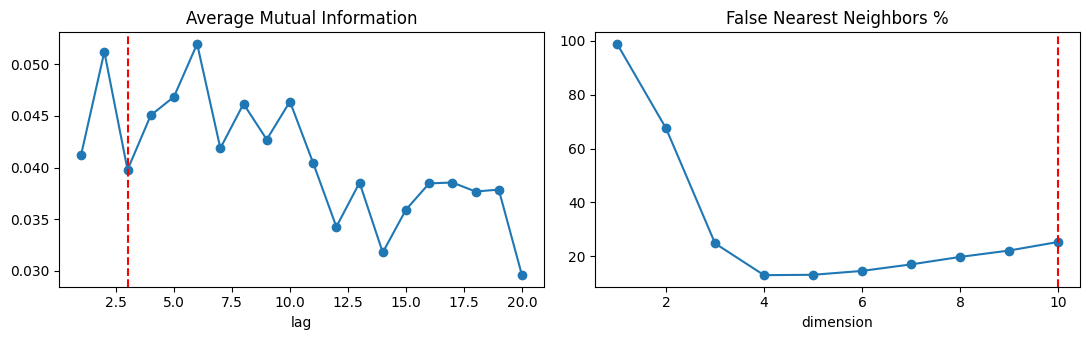

In [129]:
from sklearn.metrics import mutual_info_score
from scipy.spatial import cKDTree

def average_mutual_information(series, max_lag=20, bins=16):
    ami_vals = []
    for lag in range(1, max_lag + 1):
        x, yv = series[:-lag], series[lag:]
        c_xy = np.histogram2d(x, yv, bins=bins)[0]
        ami_vals.append(mutual_info_score(None, None, contingency=c_xy))
    return np.array(ami_vals)

def find_optimal_tau(series, max_lag=20):
    ami = average_mutual_information(series, max_lag)
    for i in range(1, len(ami) - 1):
        if ami[i] < ami[i - 1] and ami[i] < ami[i + 1]:
            return i + 1, ami
    return int(np.argmin(ami)) + 1, ami

def takens_embedding(series, tau, d):
    N = len(series)
    M = N - (d - 1) * tau
    if M <= 0:
        raise ValueError("Series too short for given tau/d")
    return np.array([series[i:i + (d - 1) * tau + 1:tau] for i in range(M)])

def false_nearest_neighbors(series, tau, max_dim=10, Rtol=15, Atol=2):
    N = len(series)
    Ra = np.std(series)
    fnn_percent = []
    for d in range(1, max_dim + 1):
        emb = takens_embedding(series, tau, d)
        M = len(emb)
        if M < 10:
            break
        tree = cKDTree(emb)
        dist, idx = tree.query(emb, k=2)
        nn_dist, nn_idx = dist[:, 1], idx[:, 1]

        false_count, valid = 0, 0
        for i in range(M):
            j = nn_idx[i]
            pt_i, pt_j = i + d * tau, j + d * tau
            if pt_i < N and pt_j < N and nn_dist[i] > 1e-10:
                dp1 = abs(series[pt_i] - series[pt_j])
                valid += 1
                ratio = dp1 / nn_dist[i]
                total_dist = np.sqrt(nn_dist[i] ** 2 + dp1 ** 2)
                if ratio > Rtol or total_dist / (Ra + 1e-12) > Atol:
                    false_count += 1
        pct = (false_count / valid * 100) if valid > 0 else 100.0
        fnn_percent.append(pct)
        if pct < 1.0 and d > 1:
            return d, fnn_percent
    return max_dim, fnn_percent

train_cutoff_for_params = int(len(df) * 0.7)
param_series = df['log_return'].values[:train_cutoff_for_params]

TAU, ami_curve = find_optimal_tau(param_series, max_lag=20)
EMBED_DIM, fnn_curve = false_nearest_neighbors(param_series, TAU, max_dim=10)
print(f"Optimal time delay tau = {TAU}")
print(f"Optimal embedding dimension d = {EMBED_DIM}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(range(1, len(ami_curve) + 1), ami_curve, marker='o')
axes[0].axvline(TAU, color='r', linestyle='--')
axes[0].set_title("Average Mutual Information"); axes[0].set_xlabel("lag")
axes[1].plot(range(1, len(fnn_curve) + 1), fnn_curve, marker='o')
axes[1].axvline(EMBED_DIM, color='r', linestyle='--')
axes[1].set_title("False Nearest Neighbors %"); axes[1].set_xlabel("dimension")
plt.tight_layout(); plt.show()

**8. Point Cloud Generation & Persistence Diagrams**

Number of diagrams: 4951
Example H0 shape: (33, 2)  H1 shape: (16, 2)


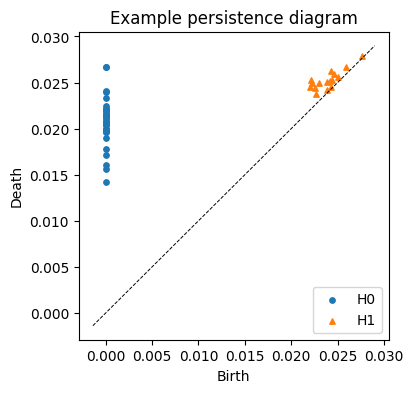

In [130]:
from ripser import ripser

# 1. Create Point Clouds using Takens embedding
point_clouds = [takens_embedding(series, TAU, EMBED_DIM) for series in X_logret]

# 2. Define Train/Val/Test Splits
n_samples = len(X_raw)
train_cutoff = int(n_samples * 0.7)
val_cutoff = int(n_samples * 0.85)

train_idx = np.arange(0, train_cutoff)
val_idx = np.arange(train_cutoff, val_cutoff)
test_idx = np.arange(val_cutoff, n_samples)

# 3. Compute Persistence Diagrams
def compute_persistence_diagrams(point_clouds, maxdim=1):
    return [ripser(pc, maxdim=maxdim)['dgms'] for pc in point_clouds]

diagrams = compute_persistence_diagrams(point_clouds, maxdim=1)
print("Number of diagrams:", len(diagrams))
print("Example H0 shape:", diagrams[0][0].shape, " H1 shape:", diagrams[0][1].shape)

# 4. Plot Example Persistence Diagram
h0, h1 = diagrams[0]
plt.figure(figsize=(4, 4))
finite_deaths = h0[h0[:, 1] < np.inf, 1]
plt.scatter(h0[:, 0], np.clip(h0[:, 1], 0, finite_deaths.max() if len(finite_deaths) else 1), label='H0', s=15)
if len(h1) > 0:
    plt.scatter(h1[:, 0], h1[:, 1], label='H1', s=15, marker='^')
lims = plt.xlim()
plt.plot(lims, lims, 'k--', linewidth=0.7)
plt.xlabel('Birth'); plt.ylabel('Death'); plt.legend(); plt.title('Example persistence diagram')
plt.show()

**9. TDA Feature Vectorization (Entropy & Persistence Images)**

In [131]:
import numpy as np
from persim import PersistenceImager
from scipy.ndimage import zoom

def persistence_entropy(dgm):
    dgm = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm) == 0:
        return 0.0
    life = dgm[:, 1] - dgm[:, 0]
    life = life[life > 0]
    if len(life) == 0:
        return 0.0
    p = life / life.sum()
    return float(-np.sum(p * np.log(p + 1e-12)))

n_total = len(diagrams)
train_cut = int(n_total * 0.7)
train_h1 = [d[1] for d in diagrams[:train_cut] if len(d[1]) > 0]

all_births = np.concatenate([d[:, 0] for d in train_h1]) if train_h1 else np.array([0.0, 1.0])
all_deaths = np.concatenate([d[:, 1] for d in train_h1]) if train_h1 else np.array([0.0, 1.0])
all_pers = all_deaths - all_births

birth_span = float(all_births.max() - all_births.min()) + 1e-6
pers_span = float(all_pers.max() - all_pers.min()) + 1e-6

birth_range = (float(all_births.min()), float(all_births.max()) + 1e-6)
pers_range = (float(all_pers.min()), float(all_pers.max()) + 1e-6)

# --- Persistence image resolution fix ---
# persim's PersistenceImager only accepts a single isotropic pixel_size, so
# whichever axis (birth or persistence) has the larger numeric span always
# gets proportionally more bins — that's what caused both the original
# 2-bin collapse and the later 83x15 blowup. Instead of fighting that with
# pixel_size arithmetic, generate the image at a moderate internal
# resolution, then resize it to a FIXED, small target shape. This makes the
# final feature count small, predictable, and independent of how the
# birth/persistence scales happen to compare.
RAW_TARGET_BINS_PER_AXIS = 20      # internal resolution before resizing
FINAL_IMAGE_SHAPE = (10, 10)       # final, fixed persistence-image size

pixel_size = float(max(min(birth_span, pers_span) / RAW_TARGET_BINS_PER_AXIS, 1e-5))

pimgr = PersistenceImager(
    birth_range=birth_range,
    pers_range=pers_range,
    pixel_size=pixel_size
)

print("Raw persistence image resolution (birth_bins, pers_bins):", pimgr.resolution)

def vectorize_diagram(dgm_pair):
    h0, h1 = dgm_pair[0], dgm_pair[1]
    ent0, ent1 = persistence_entropy(h0), persistence_entropy(h1)
    if len(h1) > 0:
        raw_img = pimgr.transform(h1)
    else:
        raw_img = np.zeros(pimgr.resolution)
    zoom_factors = (FINAL_IMAGE_SHAPE[0] / raw_img.shape[0],
                     FINAL_IMAGE_SHAPE[1] / raw_img.shape[1])
    resized_img = zoom(raw_img, zoom_factors, order=1)
    return np.concatenate([[ent0, ent1], resized_img.flatten()])

tda_features = np.array([vectorize_diagram(dgm) for dgm in diagrams])
print("TDA feature matrix shape:", tda_features.shape,
      f"({FINAL_IMAGE_SHAPE[0]}x{FINAL_IMAGE_SHAPE[1]} image + 2 entropy features)")

tda_mean = tda_features[:train_cut].mean(axis=0)
tda_std = tda_features[:train_cut].std(axis=0) + 1e-9
tda_features_scaled = (tda_features - tda_mean) / tda_std
print("tda_features_scaled created successfully!")

Raw persistence image resolution (birth_bins, pers_bins): (110, 20)
TDA feature matrix shape: (4951, 102) (10x10 image + 2 entropy features)
tda_features_scaled created successfully!


**10. Topological Signal Analysis (Crash Periods Lead Time)**

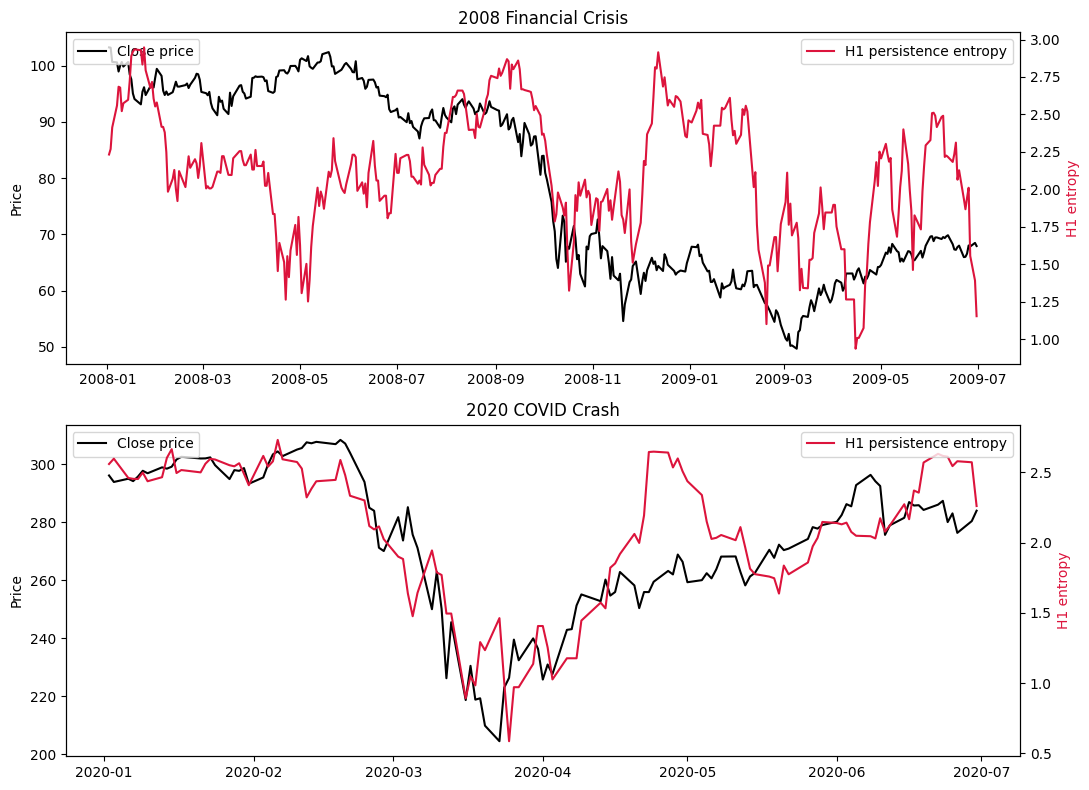

Look for entropy spikes/drops that lead the price decline.


In [132]:
crash_periods = {
    '2008 Financial Crisis': ('2008-01-01', '2009-06-30'),
    '2020 COVID Crash': ('2020-01-01', '2020-06-30'),
}

sample_dates_pd = pd.to_datetime(sample_dates)

df_indexed = df.copy()
df_indexed['Date'] = pd.to_datetime(df_indexed['Date'])
df_indexed = df_indexed.set_index('Date').sort_index()

close_at_window_end = df_indexed['Close'].reindex(sample_dates_pd, method='ffill').to_numpy()
ent1_series = tda_features[:, 1]

active_periods = {
    name: (start, end) for name, (start, end) in crash_periods.items()
    if ((sample_dates_pd >= pd.to_datetime(start)) & (sample_dates_pd <= pd.to_datetime(end))).sum() > 0
}

if not active_periods:
    print("None of the configured crash periods fall inside your date range.")
else:
    fig, axes = plt.subplots(len(active_periods), 1, figsize=(11, 4 * len(active_periods)))
    if len(active_periods) == 1:
        axes = [axes]
    for ax, (name, (start, end)) in zip(axes, active_periods.items()):
        start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end)
        mask = (sample_dates_pd >= start_dt) & (sample_dates_pd <= end_dt)
        dates_sub, price_sub, ent_sub = sample_dates_pd[mask], close_at_window_end[mask], ent1_series[mask]
        
        ax2 = ax.twinx()
        ax.plot(dates_sub, price_sub, color='black', label='Close price')
        ax2.plot(dates_sub, ent_sub, color='crimson', label='H1 persistence entropy')
        ax.set_title(name); ax.set_ylabel('Price'); ax2.set_ylabel('H1 entropy', color='crimson')
        ax.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.tight_layout(); plt.show()
    print("Look for entropy spikes/drops that lead the price decline.")

**11. PyTorch Dataset & DataLoader Construction**

In [133]:
class WindowDataset(Dataset):
    def __init__(self, X_raw, X_tda, y, idx):
        self.X_raw = torch.tensor(X_raw[idx], dtype=torch.float32)
        self.X_tda = torch.tensor(X_tda[idx], dtype=torch.float32)
        self.y = torch.tensor(y[idx], dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X_raw[i], self.X_tda[i], self.y[i]

BATCH_SIZE = 64
train_ds = WindowDataset(X_raw, tda_features_scaled, y, train_idx)
val_ds = WindowDataset(X_raw, tda_features_scaled, y, val_idx)
test_ds = WindowDataset(X_raw, tda_features_scaled, y, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

**12. Baseline LSTM Model Architecture & Training**

In [134]:
class BaselineLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
    def forward(self, x_raw, x_tda=None):
        out, (h_n, c_n) = self.lstm(x_raw)
        return self.head(h_n[-1]).squeeze(-1)

def train_model(model, train_loader, val_loader, epochs=40, lr=5e-4, patience=7, pos_weight=None):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # Compute pos_weight dynamically if not provided to handle imbalanced direction
    if pos_weight is None:
        y_train = train_loader.dataset.y
        num_pos = (y_train == 1).sum().item()
        num_neg = (y_train == 0).sum().item()
        pos_weight = torch.tensor([num_neg / (num_pos + 1e-8)], device=DEVICE)
    elif not isinstance(pos_weight, torch.Tensor):
        pos_weight = torch.tensor([pos_weight], device=DEVICE)
        
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    best_val_loss, best_state, wait = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds, train_true = [], []
        for x_raw, x_tda, yb in train_loader:
            x_raw, x_tda, yb = x_raw.to(DEVICE), x_tda.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(x_raw, x_tda)
            loss = loss_fn(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_losses.append(loss.item())
            train_preds.extend((torch.sigmoid(logits) > 0.5).long().cpu().numpy())
            train_true.extend(yb.cpu().numpy())

        model.eval()
        val_losses = []
        val_preds, val_true = [], []
        with torch.no_grad():
            for x_raw, x_tda, yb in val_loader:
                x_raw, x_tda, yb = x_raw.to(DEVICE), x_tda.to(DEVICE), yb.to(DEVICE)
                logits = model(x_raw, x_tda)
                val_losses.append(loss_fn(logits, yb).item())
                val_preds.extend((torch.sigmoid(logits) > 0.5).long().cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        tr_loss, vl_loss = np.mean(train_losses), np.mean(val_losses)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        
        pos_rate_tr = np.mean(train_preds)
        pos_rate_vl = np.mean(val_preds)
        print(f"Epoch {epoch+1:02d} | Train Loss={tr_loss:.4f} (PosPred={pos_rate_tr:.2f}) | Val Loss={vl_loss:.4f} (PosPred={pos_rate_vl:.2f})")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    return model, history

baseline_model = BaselineLSTM(n_features=X_raw.shape[-1])
baseline_model, baseline_history = train_model(baseline_model, train_loader, val_loader)

Epoch 01 | Train Loss=0.6261 (PosPred=0.00) | Val Loss=0.6240 (PosPred=0.00)
Epoch 02 | Train Loss=0.6244 (PosPred=0.07) | Val Loss=0.6223 (PosPred=0.05)
Epoch 03 | Train Loss=0.6237 (PosPred=0.24) | Val Loss=0.6214 (PosPred=0.19)
Epoch 04 | Train Loss=0.6244 (PosPred=0.44) | Val Loss=0.6209 (PosPred=0.45)
Epoch 05 | Train Loss=0.6235 (PosPred=0.44) | Val Loss=0.6214 (PosPred=0.36)
Epoch 06 | Train Loss=0.6238 (PosPred=0.35) | Val Loss=0.6212 (PosPred=0.46)
Epoch 07 | Train Loss=0.6244 (PosPred=0.51) | Val Loss=0.6214 (PosPred=0.46)
Epoch 08 | Train Loss=0.6235 (PosPred=0.39) | Val Loss=0.6217 (PosPred=0.36)
Epoch 09 | Train Loss=0.6238 (PosPred=0.47) | Val Loss=0.6216 (PosPred=0.44)
Epoch 10 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6217 (PosPred=0.47)
Epoch 11 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6223 (PosPred=0.41)
Early stopping triggered at epoch 11.


**13. Hybrid LSTM + TDA Model Architecture & Training**

In [135]:
# --- Section 13, first cell: Baseline LSTM ---

class BaselineLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
    def forward(self, x_raw, x_tda=None):
        out, (h_n, c_n) = self.lstm(x_raw)
        return self.head(h_n[-1]).squeeze(-1)

def train_model(model, train_loader, val_loader, epochs=40, lr=5e-4, patience=7, pos_weight=None):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if pos_weight is None:
        y_train = train_loader.dataset.y
        num_pos = (y_train == 1).sum().item()
        num_neg = (y_train == 0).sum().item()
        pos_weight = torch.tensor([num_neg / (num_pos + 1e-8)], device=DEVICE)
    elif not isinstance(pos_weight, torch.Tensor):
        pos_weight = torch.tensor([pos_weight], device=DEVICE)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss, best_state, wait = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds, train_true = [], []
        for x_raw, x_tda, yb in train_loader:
            x_raw, x_tda, yb = x_raw.to(DEVICE), x_tda.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(x_raw, x_tda)
            loss = loss_fn(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_losses.append(loss.item())
            train_preds.extend((torch.sigmoid(logits) > 0.5).long().cpu().numpy())
            train_true.extend(yb.cpu().numpy())

        model.eval()
        val_losses = []
        val_preds, val_true = [], []
        with torch.no_grad():
            for x_raw, x_tda, yb in val_loader:
                x_raw, x_tda, yb = x_raw.to(DEVICE), x_tda.to(DEVICE), yb.to(DEVICE)
                logits = model(x_raw, x_tda)
                val_losses.append(loss_fn(logits, yb).item())
                val_preds.extend((torch.sigmoid(logits) > 0.5).long().cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        tr_loss, vl_loss = np.mean(train_losses), np.mean(val_losses)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        pos_rate_tr = np.mean(train_preds)
        pos_rate_vl = np.mean(val_preds)
        print(f"Epoch {epoch+1:02d} | Train Loss={tr_loss:.4f} (PosPred={pos_rate_tr:.2f}) | Val Loss={vl_loss:.4f} (PosPred={pos_rate_vl:.2f})")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    return model, history

# Reseed explicitly right before model creation + training, so this cell's
# result no longer depends on how many random draws earlier cells consumed.
torch.manual_seed(SEED)
np.random.seed(SEED)

baseline_model = BaselineLSTM(n_features=X_raw.shape[-1])
baseline_model, baseline_history = train_model(baseline_model, train_loader, val_loader)

Epoch 01 | Train Loss=0.6261 (PosPred=0.00) | Val Loss=0.6240 (PosPred=0.00)
Epoch 02 | Train Loss=0.6244 (PosPred=0.07) | Val Loss=0.6223 (PosPred=0.05)
Epoch 03 | Train Loss=0.6237 (PosPred=0.24) | Val Loss=0.6214 (PosPred=0.19)
Epoch 04 | Train Loss=0.6244 (PosPred=0.44) | Val Loss=0.6209 (PosPred=0.45)
Epoch 05 | Train Loss=0.6235 (PosPred=0.44) | Val Loss=0.6214 (PosPred=0.36)
Epoch 06 | Train Loss=0.6238 (PosPred=0.35) | Val Loss=0.6212 (PosPred=0.46)
Epoch 07 | Train Loss=0.6244 (PosPred=0.51) | Val Loss=0.6214 (PosPred=0.46)
Epoch 08 | Train Loss=0.6235 (PosPred=0.39) | Val Loss=0.6217 (PosPred=0.36)
Epoch 09 | Train Loss=0.6238 (PosPred=0.47) | Val Loss=0.6216 (PosPred=0.44)
Epoch 10 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6217 (PosPred=0.47)
Epoch 11 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6223 (PosPred=0.41)
Early stopping triggered at epoch 11.


In [136]:
# --- Section 13, second cell: Hybrid Model ---

class HybridModel(nn.Module):
    def __init__(self, n_features, tda_dim, hidden_size=32, tda_hidden=16, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.tda_encoder = nn.Sequential(
            nn.Linear(tda_dim, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, tda_hidden), nn.ReLU()
        )
        self.fusion_head = nn.Sequential(
            nn.Linear(hidden_size + tda_hidden, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 1)
        )
    def forward(self, x_raw, x_tda):
        _, (h_n, _) = self.lstm(x_raw)
        seq_repr = h_n[-1]
        tda_repr = self.tda_encoder(x_tda)
        fused = torch.cat([seq_repr, tda_repr], dim=-1)
        return self.fusion_head(fused).squeeze(-1)

# Same seed as the baseline above — keeps the comparison fair: any
# difference in results comes from the architecture, not from a
# different random init draw.
torch.manual_seed(SEED)
np.random.seed(SEED)

hybrid_model = HybridModel(n_features=X_raw.shape[-1], tda_dim=tda_features_scaled.shape[-1])
hybrid_model, hybrid_history = train_model(hybrid_model, train_loader, val_loader)

Epoch 01 | Train Loss=0.6246 (PosPred=0.30) | Val Loss=0.6213 (PosPred=0.35)
Epoch 02 | Train Loss=0.6239 (PosPred=0.46) | Val Loss=0.6214 (PosPred=0.26)
Epoch 03 | Train Loss=0.6243 (PosPred=0.41) | Val Loss=0.6216 (PosPred=0.32)
Epoch 04 | Train Loss=0.6239 (PosPred=0.57) | Val Loss=0.6216 (PosPred=0.37)
Epoch 05 | Train Loss=0.6239 (PosPred=0.49) | Val Loss=0.6217 (PosPred=0.38)
Epoch 06 | Train Loss=0.6240 (PosPred=0.44) | Val Loss=0.6218 (PosPred=0.41)
Epoch 07 | Train Loss=0.6229 (PosPred=0.32) | Val Loss=0.6220 (PosPred=0.40)
Epoch 08 | Train Loss=0.6233 (PosPred=0.56) | Val Loss=0.6217 (PosPred=0.57)
Early stopping triggered at epoch 8.


**14. Financial Strategy Backtesting & Performance Evaluation**

                   accuracy  sharpe  sortino  max_drawdown  cumulative_return
Baseline LSTM        0.4953  0.1219   0.1116       -0.2438             0.0220
Hybrid (LSTM+TDA)    0.4778 -0.0183  -0.0181       -0.2176            -0.0328
Buy & Hold           0.5303  0.5362   0.7512       -0.2413             0.2611
Naive Persistence    0.5114  0.3096   0.3388       -0.1889             0.0917


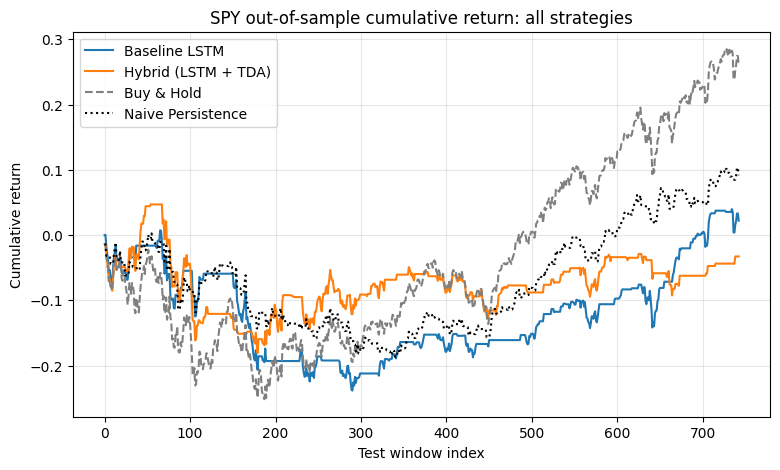

In [137]:
# --- Section 14: Financial Strategy Backtesting & Performance Evaluation ---

def get_predictions(model, loader):
    model.eval()
    probs, targets = [], []
    with torch.no_grad():
        for x_raw, x_tda, yb in loader:
            x_raw, x_tda = x_raw.to(DEVICE), x_tda.to(DEVICE)
            probs.append(torch.sigmoid(model(x_raw, x_tda)).cpu().numpy())
            targets.append(yb.numpy())
    return np.concatenate(probs), np.concatenate(targets)

def evaluate_strategy(probs, targets, test_idx, log_returns_full, threshold=0.5, cost_bps=1.0):
    preds = (probs > threshold).astype(int)
    accuracy = float((preds == targets).mean())

    realized = log_returns_full[test_idx]
    position = np.where(preds == 1, 1.0, 0.0)
    turnover = np.abs(np.diff(np.concatenate([[0], position])))
    cost = turnover * (cost_bps / 10000.0)

    strat_returns = position * realized - cost
    cum_returns = np.cumprod(1 + strat_returns) - 1

    mean_ret, std_ret = strat_returns.mean(), strat_returns.std() + 1e-9
    sharpe = (mean_ret / std_ret) * np.sqrt(252)

    downside = strat_returns[strat_returns < 0]
    downside_std = downside.std() + 1e-9 if len(downside) > 0 else 1e-9
    sortino = (mean_ret / downside_std) * np.sqrt(252)

    running_max = np.maximum.accumulate(1 + cum_returns)
    drawdown = (1 + cum_returns) / running_max - 1
    mdd = float(drawdown.min())

    return {
        'accuracy': accuracy, 'sharpe': float(sharpe), 'sortino': float(sortino),
        'max_drawdown': mdd, 'cumulative_return': float(cum_returns[-1]),
    }, cum_returns

close_full = df['Close'].values
realized_returns_all = np.array([
    np.log(close_full[i+WINDOW+HORIZON-1]) - np.log(close_full[i+WINDOW-1])
    for i in range(0, len(df) - WINDOW - HORIZON, STRIDE)
])
assert len(realized_returns_all) == len(y)

baseline_probs, baseline_targets = get_predictions(baseline_model, test_loader)
hybrid_probs, hybrid_targets = get_predictions(hybrid_model, test_loader)

baseline_metrics, baseline_cum = evaluate_strategy(baseline_probs, baseline_targets, test_idx, realized_returns_all)
hybrid_metrics, hybrid_cum = evaluate_strategy(hybrid_probs, hybrid_targets, test_idx, realized_returns_all)

# --- context baselines: Buy & Hold, Naive Persistence ---
buy_hold_probs = np.ones(len(test_idx))
buy_hold_targets = y[test_idx]
buy_hold_metrics, buy_hold_cum = evaluate_strategy(buy_hold_probs, buy_hold_targets, test_idx, realized_returns_all)

naive_signal = (X_logret[test_idx, -1] > 0).astype(float)
naive_targets = y[test_idx]
naive_metrics, naive_cum = evaluate_strategy(naive_signal, naive_targets, test_idx, realized_returns_all)

comparison = pd.DataFrame(
    [baseline_metrics, hybrid_metrics, buy_hold_metrics, naive_metrics],
    index=['Baseline LSTM', 'Hybrid (LSTM+TDA)', 'Buy & Hold', 'Naive Persistence']
)
print(comparison.round(4))

plt.figure(figsize=(9, 5))
plt.plot(baseline_cum, label='Baseline LSTM')
plt.plot(hybrid_cum, label='Hybrid (LSTM + TDA)')
plt.plot(buy_hold_cum, label='Buy & Hold', linestyle='--', color='gray')
plt.plot(naive_cum, label='Naive Persistence', linestyle=':', color='black')
plt.xlabel('Test window index'); plt.ylabel('Cumulative return')
plt.title(f'{TICKER} out-of-sample cumulative return: all strategies')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**15. Ablation Study**

In [138]:
ABLATION_EPOCHS = 40
ABLATION_LR = 5e-4
ABLATION_PATIENCE = 7

tda_h0_scaled = tda_features_scaled[:, :1]
tda_h1_scaled = tda_features_scaled[:, 1:]

ablation_configs = {
    'Raw-only': {'use_raw': True, 'tda_data': None, 'dim': 0},
    'TDA-only': {'use_raw': False, 'tda_data': tda_features_scaled, 'dim': tda_features_scaled.shape[1]},
    'H0-only':  {'use_raw': True, 'tda_data': tda_h0_scaled, 'dim': tda_h0_scaled.shape[1]},
    'H1-only':  {'use_raw': True, 'tda_data': tda_h1_scaled, 'dim': tda_h1_scaled.shape[1]},
    'Hybrid':   {'use_raw': True, 'tda_data': tda_features_scaled, 'dim': tda_features_scaled.shape[1]}
}

class TDAOnlyModel(nn.Module):
    def __init__(self, tda_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(tda_dim, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x_raw, x_tda):
        return self.net(x_tda).squeeze(-1)

ablation_results = {}

for name, cfg in ablation_configs.items():
    print(f"\n--- Running Ablation: {name} ---")

    # Reseed before every config so each model starts from the same
    # controlled state — makes results reproducible and comparable
    # across configs instead of depending on however much randomness
    # earlier configs happened to consume.
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    tda_sub = cfg['tda_data'] if cfg['tda_data'] is not None else np.zeros((len(X_raw), 1))

    tr_ds = WindowDataset(X_raw, tda_sub, y, train_idx)
    vl_ds = WindowDataset(X_raw, tda_sub, y, val_idx)
    ts_ds = WindowDataset(X_raw, tda_sub, y, test_idx)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False)
    ts_loader = DataLoader(ts_ds, batch_size=BATCH_SIZE, shuffle=False)

    if name == 'Raw-only':
        m = BaselineLSTM(n_features=X_raw.shape[-1])
    elif name == 'TDA-only':
        m = TDAOnlyModel(tda_dim=cfg['dim'])
    else:
        m = HybridModel(n_features=X_raw.shape[-1], tda_dim=cfg['dim'])

    m, _ = train_model(m, tr_loader, vl_loader, epochs=ABLATION_EPOCHS, lr=ABLATION_LR, patience=ABLATION_PATIENCE)
    probs, targets = get_predictions(m, ts_loader)
    metrics, _ = evaluate_strategy(probs, targets, test_idx, realized_returns_all)
    ablation_results[name] = metrics

ablation_df = pd.DataFrame(ablation_results).T
print("\n=== Ablation Study Summary ===")
print(ablation_df.round(4))


--- Running Ablation: Raw-only ---
Epoch 01 | Train Loss=0.6261 (PosPred=0.00) | Val Loss=0.6240 (PosPred=0.00)
Epoch 02 | Train Loss=0.6244 (PosPred=0.07) | Val Loss=0.6223 (PosPred=0.05)
Epoch 03 | Train Loss=0.6237 (PosPred=0.24) | Val Loss=0.6214 (PosPred=0.19)
Epoch 04 | Train Loss=0.6244 (PosPred=0.44) | Val Loss=0.6209 (PosPred=0.45)
Epoch 05 | Train Loss=0.6235 (PosPred=0.44) | Val Loss=0.6214 (PosPred=0.36)
Epoch 06 | Train Loss=0.6238 (PosPred=0.35) | Val Loss=0.6212 (PosPred=0.46)
Epoch 07 | Train Loss=0.6244 (PosPred=0.51) | Val Loss=0.6214 (PosPred=0.46)
Epoch 08 | Train Loss=0.6235 (PosPred=0.39) | Val Loss=0.6217 (PosPred=0.36)
Epoch 09 | Train Loss=0.6238 (PosPred=0.47) | Val Loss=0.6216 (PosPred=0.44)
Epoch 10 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6217 (PosPred=0.47)
Epoch 11 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6223 (PosPred=0.41)
Early stopping triggered at epoch 11.

--- Running Ablation: TDA-only ---
Epoch 01 | Train Loss=0.6262 (PosPred=0.22)

**16. Multi-Seed Stability & Bootstrap Confidence Intervals**

In [139]:
from scipy import stats

# --- Section 16: Multi-Seed Stability & Significance Testing ---

STABILITY_EPOCHS = 40
STABILITY_LR = 5e-4
STABILITY_PATIENCE = 7

seeds = [13, 42, 101, 2024, 777, 3407, 8, 99]  # 8 seeds for a tighter estimate
stability_records = []

for seed in seeds:
    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    vl_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    ts_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    torch.manual_seed(seed); np.random.seed(seed)
    b_model = BaselineLSTM(n_features=X_raw.shape[-1])
    b_model, _ = train_model(b_model, tr_loader, vl_loader, epochs=STABILITY_EPOCHS, lr=STABILITY_LR, patience=STABILITY_PATIENCE)
    b_p, b_t = get_predictions(b_model, ts_loader)
    b_m, _ = evaluate_strategy(b_p, b_t, test_idx, realized_returns_all)
    b_m['Model'] = 'Baseline LSTM'; b_m['Seed'] = seed
    stability_records.append(b_m)

    torch.manual_seed(seed); np.random.seed(seed)  # same seed, so both models get a controlled (not carried-over) init
    h_model = HybridModel(n_features=X_raw.shape[-1], tda_dim=tda_features_scaled.shape[-1])
    h_model, _ = train_model(h_model, tr_loader, vl_loader, epochs=STABILITY_EPOCHS, lr=STABILITY_LR, patience=STABILITY_PATIENCE)
    h_p, h_t = get_predictions(h_model, ts_loader)
    h_m, _ = evaluate_strategy(h_p, h_t, test_idx, realized_returns_all)
    h_m['Model'] = 'Hybrid (LSTM+TDA)'; h_m['Seed'] = seed
    stability_records.append(h_m)

stability_df = pd.DataFrame(stability_records)
summary_df = stability_df.groupby('Model')[['accuracy', 'sharpe', 'sortino', 'cumulative_return']].agg(['mean', 'std'])
print("\n=== Multi-Seed Stability (Mean ± Std) ===")
print(summary_df.round(4))

# --- Paired comparison across seeds ---
baseline_df = stability_df[stability_df['Model'] == 'Baseline LSTM'].reset_index(drop=True)
hybrid_df = stability_df[stability_df['Model'] == 'Hybrid (LSTM+TDA)'].reset_index(drop=True)

print("\n=== Paired Significance Tests (Hybrid vs. Baseline, per seed) ===")
for metric in ['accuracy', 'sharpe', 'sortino', 'cumulative_return']:
    diff = hybrid_df[metric].values - baseline_df[metric].values

    rng = np.random.default_rng(0)
    boot_means = [rng.choice(diff, size=len(diff), replace=True).mean() for _ in range(5000)]
    ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

    if len(diff) >= 6 and not np.all(diff == diff[0]):
        _, w_p = stats.wilcoxon(hybrid_df[metric].values, baseline_df[metric].values)
        p_str = f"{w_p:.4f}"
    else:
        p_str = "n/a (too few seeds or no variation)"

    print(f"{metric:>18}: mean diff = {diff.mean():+.4f}, 95% CI = [{ci_low:+.4f}, {ci_high:+.4f}], Wilcoxon p = {p_str}")

Epoch 01 | Train Loss=0.6270 (PosPred=0.00) | Val Loss=0.6258 (PosPred=0.00)
Epoch 02 | Train Loss=0.6253 (PosPred=0.01) | Val Loss=0.6236 (PosPred=0.00)
Epoch 03 | Train Loss=0.6250 (PosPred=0.07) | Val Loss=0.6227 (PosPred=0.08)
Epoch 04 | Train Loss=0.6241 (PosPred=0.18) | Val Loss=0.6226 (PosPred=0.14)
Epoch 05 | Train Loss=0.6243 (PosPred=0.24) | Val Loss=0.6220 (PosPred=0.30)
Epoch 06 | Train Loss=0.6236 (PosPred=0.37) | Val Loss=0.6221 (PosPred=0.29)
Epoch 07 | Train Loss=0.6239 (PosPred=0.39) | Val Loss=0.6217 (PosPred=0.44)
Epoch 08 | Train Loss=0.6229 (PosPred=0.48) | Val Loss=0.6217 (PosPred=0.47)
Epoch 09 | Train Loss=0.6234 (PosPred=0.44) | Val Loss=0.6220 (PosPred=0.42)
Epoch 10 | Train Loss=0.6221 (PosPred=0.53) | Val Loss=0.6222 (PosPred=0.41)
Epoch 11 | Train Loss=0.6226 (PosPred=0.47) | Val Loss=0.6226 (PosPred=0.42)
Epoch 12 | Train Loss=0.6229 (PosPred=0.46) | Val Loss=0.6228 (PosPred=0.37)
Epoch 13 | Train Loss=0.6219 (PosPred=0.44) | Val Loss=0.6225 (PosPred=0.49)